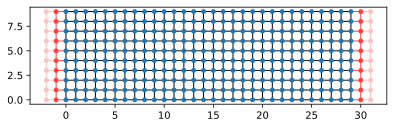

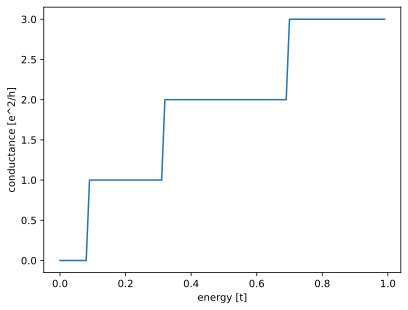

In [1]:
# Physics background
# ------------------
#  Conductance of a quantum wire; subbands
#
# Kwant features highlighted
# --------------------------
#  - Builder for setting up transport systems easily
#  - Making scattering region and leads
#  - Using the simple sparse solver for computing Landauer conductance
import kwant
from matplotlib import pyplot
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')


def make_system(L, W, a=1, t=1.0):
    lat = kwant.lattice.square(a, norbs=1)

    syst = kwant.Builder()
    syst[(lat(i, j) for i in range(L) for j in range(W))] = 4 * t
    syst[lat.neighbors()] = -t

    lead = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
    lead[(lat(0, j) for j in range(W))] = 4 * t
    lead[lat.neighbors()] = -t

    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())

    return syst

def plot_conductance(syst, energies):
    # Compute conductance
    data = []
    for energy in energies:
        smatrix = kwant.smatrix(syst, energy)
        data.append(smatrix.transmission(1, 0))

    pyplot.figure()
    pyplot.plot(energies, data)
    pyplot.xlabel("energy [t]")
    pyplot.ylabel("conductance [e^2/h]")
    pyplot.show()


def main():
    syst = make_system(W=10, L=30)

    # Check that the system looks as intended.
    kwant.plot(syst)

    # Finalize the system.
    fsyst = syst.finalized()

    # We should see conductance steps.
    plot_conductance(fsyst, energies=[0.01 * i for i in range(100)])

if __name__ == '__main__':
    main()